In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df=pd.read_csv("C:\creativa_datasets\spatial_data.csv")

In [4]:
df.head()

,X_Coordinate,Y_Coordinate
0,29.970162,62.959614
1,34.361253,13.617757
2,41.767192,59.666767
3,42.702611,67.590818
4,59.964128,55.983022


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   X_Coordinate  5400 non-null   float64
 1   Y_Coordinate  5500 non-null   float64
dtypes: float64(2)
memory usage: 86.1 KB


In [6]:
df.dropna(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5400 entries, 0 to 5499
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   X_Coordinate  5400 non-null   float64
 1   Y_Coordinate  5400 non-null   float64
dtypes: float64(2)
memory usage: 126.6 KB


In [8]:
df.describe()

,X_Coordinate,Y_Coordinate
count,5400.000000,5400.000000
mean,49.995488,49.211226
std,15.012663,17.432738
min,-7.845630,-100.000000
25%,39.616153,39.462994
50%,49.982779,49.960533
75%,60.363536,59.840942
max,109.134965,98.230613


In [10]:
df=df[(df['X_Coordinate']>=0)&(df['Y_Coordinate']>=0)]

In [12]:
df.describe()

,X_Coordinate,Y_Coordinate
count,5365.000000,5365.000000
mean,50.024584,49.931567
std,14.944036,14.680185
min,0.566582,4.164366
25%,39.739348,39.687143
50%,50.001078,50.039342
75%,60.357987,59.917715
max,109.134965,98.230613


d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` w

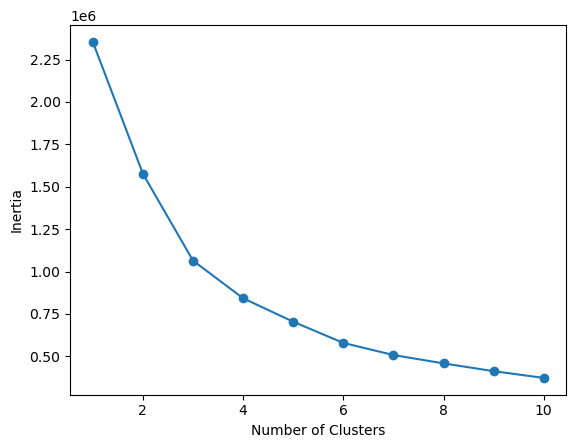

In [14]:
inertia=[]
krange=range(1,11)
for k in krange:
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)
    
plt.plot(krange,inertia,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [25]:
optimal_k=3
model=KMeans(n_clusters=optimal_k)
df["label"]=model.fit_predict(df)

d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [26]:
score=silhouette_score(df,df["label"])
score

0.3373986695196582

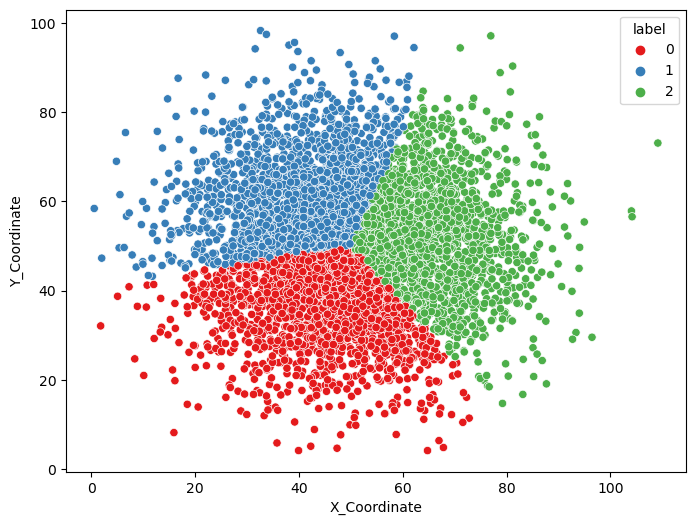

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x="X_Coordinate",y="Y_Coordinate",hue="label",palette="Set1")
plt.show()